In [346]:
import os
import warnings
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr, spearmanr
from torch.nn.functional import softmax, cosine_similarity
import logging
import torch
import torch.nn as nn
import numpy as np
import scipy.sparse as sp
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
import torch.nn.functional as F
warnings.filterwarnings("ignore")

def setup_device():
    """Set device to GPU if available, otherwise CPU."""  # prefer cuda:1 if exists
    return torch.device('cuda:2' if torch.cuda.is_available() else 'cpu')

def create_similarity_graph(Y, k=15):
    """Create spatial similarity graph using Gaussian kernel on kNN distances."""  # returns (n_spots, n_spots)
    n_spots = Y.shape[0]
    k = min(k, n_spots - 1)
    knn = NearestNeighbors(n_neighbors=k + 1).fit(Y)
    distances, indices = knn.kneighbors(Y)
    S = np.zeros((n_spots, n_spots))
    for i in range(n_spots):
        sigma = max(np.median(distances[i, 1:]), 1e-8)
        for j_idx, j in enumerate(indices[i]):
            if i != j:
                S[i, j] = np.exp(-distances[i, j_idx] ** 2 / (2 * sigma ** 2))
    if np.sum(S) == 0:
        S += np.random.random(S.shape) * 0.01
    return torch.FloatTensor(S)

def find_highly_variable_genes(adata, n_top_genes=1000):
    """Find HVGs using Seurat v3 flavor; fallback to cell_ranger if needed."""  # returns gene indices
    try:
        sc.pp.highly_variable_genes(adata, n_top_genes=n_top_genes)
    except:
        #sc.pp.filter_genes(adata, min_cells=3)
        sc.pp.normalize_total(adata)
        sc.pp.log1p(adata)
        sc.pp.highly_variable_genes(adata, n_top_genes=n_top_genes)
    return np.where(adata.var['highly_variable'])[0]

def find_common_genes_from_hvg(adata_sc, adata_ST, n_top_genes=1000):
    """Return sorted list of common HVGs between sc and ST data."""  # list of gene names
    adata_sc1=adata_sc.copy()
    adata_ST1=adata_ST.copy()
    sc_genes = set(adata_sc.var_names[find_highly_variable_genes(adata_sc1, n_top_genes)])
    st_genes = set(adata_ST.var_names[find_highly_variable_genes(adata_ST1, n_top_genes)])
    return sorted(sc_genes & st_genes)

def compute_scale_factor(X_sc, X_st):
    """Compute global scale factor = total ST counts / total sc counts."""  # scalar tensor
    return torch.sum(X_st) / torch.sum(X_sc)

def initialize_assignment_matrix(model, X_sc, X_st, n_neighbors=15):
    """Initialize A using kNN in PCA space (soft assignment)."""  # modifies model.A in-place
    device = setup_device()
    X_sc_np = X_sc.cpu().numpy() if torch.is_tensor(X_sc) else X_sc
    X_st_np = X_st.cpu().numpy() if torch.is_tensor(X_st) else X_st
    combined = np.vstack([X_sc_np, X_st_np])
    combined = np.nan_to_num(combined, nan=0.0)
    row_sums = combined.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums == 0, 1.0, row_sums)
    normalized = combined / row_sums * row_sums.mean()
    pca = PCA(n_components=min(50, normalized.shape[1]))
    sc_pca = pca.fit_transform(normalized)[:X_sc_np.shape[0]]
    st_pca = pca.transform(normalized)[X_sc_np.shape[0]:]
    knn = NearestNeighbors(n_neighbors=min(n_neighbors, sc_pca.shape[0] - 1)).fit(sc_pca)
    _, indices = knn.kneighbors(st_pca)
    A_init = torch.zeros(model.n_st_spots, model.n_sc_cells)
    A_init = np.log(1e-10)*A_init
    for i in range(model.n_st_spots):
        A_init[i, indices[i]] = np.log(1.0 / len(indices[i]))  # uniform init over neighbors
    A_init=torch.tensor(np.random.normal(0,1,(model.n_st_spots, model.n_sc_cells)),dtype=torch.float32)
    model.A.data = A_init.to(device)
    return sc_pca

def load_and_align_data(sc_path, st_path, n_top_genes=1000,common_genes=None):
    """Load, filter, and align sc/ST data on common HVGs."""  # returns tensors + metadata
    adata_ST = sc.read(st_path)
    adata_sc = sc.read(sc_path)
    #sc.pp.filter_genes(adata_sc, min_cells=3); sc.pp.filter_cells(adata_sc, min_genes=200)
    #sc.pp.filter_genes(adata_ST, min_cells=3); sc.pp.filter_cells(adata_ST, min_genes=200)
    if common_genes is None:
        common_genes = find_common_genes_from_hvg(adata_sc, adata_ST, n_top_genes)
    print('the number of common gene are',len(common_genes))
    assert len(common_genes) >= 100, "Too few common HVGs (<100)"
    common_genes=list(set(common_genes)&set(adata_ST.var_names))
    common_genes=list(set(common_genes)&set(adata_sc.var_names))
    X_sc = adata_sc[:, common_genes].X.toarray() if hasattr(adata_sc.X, 'toarray') else adata_sc[:, common_genes].X
    X_st = adata_ST[:, common_genes].X.toarray() if hasattr(adata_ST.X, 'toarray') else adata_ST[:, common_genes].X
    X_sc, X_st = torch.FloatTensor(X_sc), torch.FloatTensor(X_st)
    Y = torch.FloatTensor(adata_ST.obsm['spatial']) if 'spatial' in adata_ST.obsm else None
    return X_sc, X_st, Y, adata_sc, adata_ST, common_genes


def compute_column_sum_loss(tensor, target_sum=1.0):
    """L2 penalty on column sums deviating from target_sum."""  # scalar
    col_sums = tensor.sum(dim=0)
    return F.mse_loss(col_sums, torch.full_like(col_sums, target_sum), reduction='sum')

class VAEImprovedSpatialModel(nn.Module):
    def __init__(self, n_sc_cells, n_st_spots, n_genes, embedding_dim=8,
                 lambda_reg=0, lambda_l2=1,lambda_l4=0,lambda_l5=0, lambda_ot=-1, lambda_M=1, lambda_M1=1,lambda_r=0, lambda_kl=0.1,lambda_pca=1,lambda_f=1, lambda_row_sum=1.0):
        super().__init__()
        self.n_sc_cells = n_sc_cells
        self.n_st_spots = n_st_spots
        self.n_genes = n_genes
        self.embedding_dim = embedding_dim
        self.lambda_reg = lambda_reg
        self.lambda_l2 = lambda_l2
        self.lambda_l4 = lambda_l4
        self.lambda_l5 = lambda_l5
        self.lambda_ot = lambda_ot
        self.lambda_r = lambda_r
        self.lambda_M = lambda_M
        self.lambda_M1 = lambda_M1
        self.lambda_kl = lambda_kl  # 新增 KL 权重
        self.lambda_pca = lambda_pca
        self.lambda_f = lambda_f
        self.lambda_row_sum = lambda_row_sum
        self._density_criterion = torch.nn.KLDivLoss(reduction="mean")
        # --- Gene embedding (still learnable) ---
        # --- Encoder for single-cell counts (VAE style) ---
        self.encoder = nn.Sequential(
            nn.Linear(n_genes, 128),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64), nn.ReLU()
        )
        self.fc_mu = nn.Linear(64, embedding_dim)
        self.fc_logvar = nn.Linear(64, embedding_dim)
        # --- Decoder: reconstruct expression from z_cell and z_gene ---
        self.decoder = nn.Sequential(
            nn.Linear(embedding_dim, 64),
            nn.BatchNorm1d(64), nn.ReLU(),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, n_genes),
            nn.Softplus()  # ensures λ > 0 for Poisson
        )
        # --- Assignment matrix A ---
        device = setup_device()
        #self.A = nn.Parameter(torch.randn(n_st_spots, n_sc_cells, device=device) * 0.01)
        self.A = np.random.normal(0, 1, (n_st_spots, n_sc_cells))
        self.A = nn.Parameter(torch.tensor(self.A, device=device, requires_grad=True, dtype=torch.float32))
        self.f = nn.Parameter(torch.randn( n_sc_cells,1, device=device) * 0.01)
        self.log_scale = nn.Parameter(torch.tensor(0.0))  # for ST scaling

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def encode_sc(self, X_sc):
        # X_sc: (n_cells, n_genes), raw counts (non-negative)
        h = self.encoder(X_sc)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        logvar = torch.clamp(logvar, min=-10, max=10)
        z = self.reparameterize(mu, logvar)
        return z, mu, logvar

    def decode_expression(self, z_cell):
        # z_cell: (n_cells, d), z_gene: (n_genes, d)
        #z_cell_exp = z_cell.unsqueeze(1).expand(-1, self.n_genes, -1)   # (n, g, d)
        out = self.decoder(z_cell)    # (n*g, 1)
        return out                   # (n, g)

    def compute_softmax_A(self):
        return F.softmax(self.A, dim=0)

    def compute_st_embedding(self, z_cell):
        A_hat = self.compute_softmax_A()
        return torch.mm(A_hat, z_cell)

    def kl_loss(self, mu, logvar):
        #print(mu,logvar)
        logvar = torch.clamp(logvar, min=-10, max=10)
        # KL divergence between q(z|x) and N(0,I)
        return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    def poisson_nll_loss(self, y_true, lam):
        lam = torch.clamp(lam, min=1e-8)
        # y_true: non-negative integers, lam: positive reals
        return F.poisson_nll_loss(
            input=torch.log(lam + 1e-8),
            target=y_true,
            log_input=True,
            full=False,
            reduction='mean'
        )

    def loss_L1(self, X_sc, f_vals):
        return self.poisson_nll_loss(X_sc, f_vals)
    def loss_L1_cos(self, X_sc, f_vals):
        gv = 1 - 0.5 * cosine_similarity(f_vals, X_sc, dim=0).mean()
        vg = 1 - 0.5 * cosine_similarity(f_vals, X_sc, dim=1).mean()
        return gv+vg
    def loss_L2(self, X_st, f_vals):
        #scale = torch.exp(self.log_scale)
        #X_st_pred = torch.mm(scale * self.compute_softmax_A(), f_vals)
        f_sigmoid = torch.sigmoid(self.f)
        A_softmax = self.compute_softmax_A()
        s_vec = f_sigmoid.squeeze()  
        if f_vals.dim() == 1:
            weighted_vec = s_vec * f_vals       # Shape: [152687]
        else:
            weighted_vec = s_vec.unsqueeze(-1) * f_vals # Shape: [152687, D]
        weighted_vec = f_vals
        if weighted_vec.dim() == 1:
    # 矩阵 x 向量 -> 结果向量
            X_st_pred = torch.mv(A_softmax, weighted_vec) 
    # 或者: X_st_pred = A_softmax @ weighted_vec
        else:
    # 矩阵 x 矩阵 -> 结果矩阵
            X_st_pred = torch.mm(A_softmax, weighted_vec)
        return self.poisson_nll_loss(X_st, X_st_pred)

    def loss_L3(self, z_st, S):
        diff = z_st.unsqueeze(1) - z_st.unsqueeze(0)
        sq_diff = torch.mean(diff ** 2, dim=2)
        return torch.sum(S * sq_diff) if torch.sum(S) > 0 else torch.sum(sq_diff) * 1e-6

    def loss_LM(self, X_sc, X_st):
        f_sigmoid = torch.sigmoid(self.f)
        M_probs = self.compute_softmax_A()
        #print(M_probs.shape, f_sigmoid.shape, X_sc.shape)
        f_sigmoid=1
        #weighted_X_sc = f_sigmoid * X_sc 
        weighted_X_sc = f_sigmoid * X_sc 
        G_pred = torch.matmul(M_probs, X_sc)
        #G_pred = torch.matmul(M_probs,torch.diag(f_sigmoid.squeeze())@ X_sc)
        gv = 1 - 0.5 * cosine_similarity(G_pred, X_st, dim=0).mean()
        vg = 1 - 0.5 * cosine_similarity(G_pred, X_st, dim=1).mean()
        return gv #+ vg

    def A_entropy(self, M):
        eps = 1e-8
        #print(M.shape)
        return -( torch.log(M.T)*(M.T)).sum()
    def custom_loss(self):
        f_sigmoid = torch.sigmoid(self.f)
        return torch.mean(f_sigmoid - f_sigmoid**2)
    def row_sum_mse_loss(self, num_cell):
        sigmoid_f = torch.sigmoid(self.f).squeeze()
        softmax_A = F.softmax(self.A, dim=0)
        A = softmax_A #* sigmoid_f 
        row_sums = A.sum(dim=1)/A.sum()
        row_sums=torch.log(row_sums)
        num_cell=num_cell/num_cell.sum()
        similarity = F.cosine_similarity(row_sums.unsqueeze(0), num_cell.unsqueeze(0), dim=1).mean()
        #return F.mse_loss(row_sums, num_cell, reduction='mean')
        density_term=self._density_criterion(row_sums.unsqueeze(0), num_cell.unsqueeze(0))
        return density_term

    def forward(self, X_sc, X_st, S, C=None,num_cell=None,z_pca=None):
        target_dtype = next(self.parameters()).dtype
    
    # 2. 定义一个辅助函数来转换张量
        def ensure_dtype(tensor):
            if tensor is None:
                return None
            if tensor.dtype != target_dtype:
                return tensor.to(target_dtype)
            return tensor
        X_sc = ensure_dtype(X_sc)
        X_st = ensure_dtype(X_st)
        S = ensure_dtype(S)
        C = ensure_dtype(C)
        num_cell = ensure_dtype(num_cell)
        # Encode single-cell data → z_cell
        z_cell, mu, logvar = self.encode_sc(X_sc)  # important: float!
        # Decode to get λ (Poisson rate)
        f_vals = self.decode_expression(z_cell)  # already >0 due to Softplus
        # Compute spatial embedding
        z_st = self.compute_st_embedding(z_cell)

        # Losses
        l1 = self.loss_L1(X_sc, f_vals)
        l2 = self.loss_L2(X_st, f_vals)
        l3 = self.loss_L3(z_st, S)
        LM = self.loss_LM(X_sc, X_st)  # 注意：这里用 f_vals 代替 X_sc 更合理
        LM1 = self.loss_LM(f_vals, X_st)
        M_soft = self.compute_softmax_A()
        L_E = self.A_entropy(M_soft)

        l4=self.lambda_l4*self.A.abs().sum()
        l5=self.lambda_l5*(self.A**2).sum()
        kl = self.kl_loss(mu, logvar)
        z_pca=torch.tensor(z_pca, device=X_sc.device, dtype=torch.float32)
        #print(z_cell.shape, z_pca.shape)
        loss_align = F.mse_loss(z_cell, z_pca).mean()
        l_f=self.custom_loss()


        # optional row-sum loss (requires num_cell to be provided)
        row_sum_loss = torch.tensor(0.0, device=X_sc.device)
        if num_cell is not None:
            # ensure num_cell tensor on correct device and dtype
            if not torch.is_tensor(num_cell):
                num_cell = torch.tensor(num_cell, device=X_sc.device, dtype=torch.float32)
            else:
                num_cell = num_cell.to(X_sc.device,dtype=torch.float32)
            row_sum_loss = self.row_sum_mse_loss(num_cell)
        total = (
            l1 +
            self.lambda_l2 * l2 +
            self.lambda_l4 * l4 +
            self.lambda_l5 * l5 +
            self.lambda_reg * l3 +
            self.lambda_M * LM +
            self.lambda_M1 * LM1 +
            self.lambda_r * L_E +
            self.lambda_kl * kl+ 
            self.lambda_pca * loss_align+
            self.lambda_f *l_f +
            self.lambda_row_sum * row_sum_loss
        )

        B_mean = torch.tensor(0.0, device=X_sc.device)
        if C is not None:
            A_softmax = self.compute_softmax_A()
            B = (1 - C / 2) * A_softmax
            B_mean = B.mean()
            total += self.lambda_ot * B_mean

        return total, l1, l2, l3,l4,l5, kl, B_mean, LM, LM1, L_E,loss_align,l_f, row_sum_loss
        #return  LM

def plot_training_losses(losses, output_dir='evaluation'):
    """Plot and save training loss curves."""  # saves to output_dir/training_losses.png
    os.makedirs(output_dir, exist_ok=True)
    epochs = [l['epoch'] for l in losses]
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    axs[0,0].plot(epochs, [l['total'] for l in losses], 'b-'); axs[0,0].set_title('Total Loss')
    axs[0,1].plot(epochs, [l['l1'] for l in losses], 'r-', label='L1'); axs[0,1].plot(epochs, [l['l2'] for l in losses], 'g-', label='L2')
    axs[0,1].legend(); axs[0,1].set_title('L1 & L2')
    axs[1,0].plot(epochs, [l['l3'] for l in losses], 'purple'); axs[1,0].set_title('L3 (Smoothness)')
    axs[1,1].plot(epochs, [l['l1']+l['l2'] for l in losses], 'orange'); axs[1,1].set_title('L1 + L2')
    for ax in axs.flat: ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/training_losses.png', dpi=300, bbox_inches='tight')
    plt.close()

def train_vae_poisson_model(sc_path, st_path, C=None, num_cell=None, output_dir='SpatialVG_VAE_Poisson',common_genes=None,
                            embedding_dim=8, lr=0.01, epochs=300,
                            lambda_reg=0.5, lambda_l2=1,lambda_l4=1,lambda_l5=1, lambda_ot=-1,
                            lambda_M=1, lambda_M1=1,lambda_r=-10000, lambda_kl=0.1, lambda_pca=1,lambda_f=1, lambda_row_sum=1.0,
                            n_top_genes=1000):
    device = setup_device()
    os.makedirs(f'{output_dir}/models', exist_ok=True)
    os.makedirs(f'{output_dir}/evaluation', exist_ok=True)

    X_sc, X_st, Y, adata_sc, adata_ST, genes = load_and_align_data(sc_path, st_path, n_top_genes=n_top_genes,common_genes=common_genes)
    X_sc=np.log(X_sc+1)
    X_st=np.log(X_st+1)
    S = create_similarity_graph(Y.numpy()) if Y is not None else torch.zeros(X_st.shape[0], X_st.shape[0])
    X_sc, X_st, S = X_sc.to(device), X_st.to(device), S.to(device)

    model = VAEImprovedSpatialModel(
        n_sc_cells=X_sc.shape[0],
        n_st_spots=X_st.shape[0],
        n_genes=X_sc.shape[1],
        embedding_dim=embedding_dim,
        lambda_reg=lambda_reg,
        lambda_l2=lambda_l2,
        lambda_l4=lambda_l4,
        lambda_l5=lambda_l5,
        lambda_ot=lambda_ot,
        lambda_M=lambda_M,
        lambda_M1=lambda_M1,
        lambda_r=lambda_r,
        lambda_kl=lambda_kl,
        lambda_pca=lambda_pca,lambda_f=lambda_f, lambda_row_sum=lambda_row_sum
    ).to(device)
    # model = nn.DataParallel(model)
    pca_sc=initialize_assignment_matrix(model, X_sc, X_st, n_neighbors=15)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.8)

    best_loss, patience = float('inf'), 0
    losses = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        total, l1, l2, l3,l4,l5, kl, loss_ot, LM,LM1, L_E,loss_align,l_f, row_sum = model(X_sc, X_st, S, C,num_cell,pca_sc[:,:embedding_dim])
        if torch.isnan(total).any():
            print(f"NaN detected at epoch {epoch}. Stopping training.")
            break
        total.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        losses.append({
            'epoch': epoch,
            'total': total.item(),
            'l1': l1.item(),
            'l2': l2.item(),
            'l3': l3.item(),
            'kl': kl.item(),
            'loss_ot': loss_ot.item(),
            'loss_M': LM.item(),
            'loss_M1': LM1.item(),
            'loss_En': L_E.item(),
            'loss_align':loss_align.item(),
            'loss_f':l_f.item(),
            'loss_row_sum': row_sum.item()
        })

        if total.item() < best_loss:
            best_loss, patience = total.item(), 0
            torch.save({
                'model_state_dict': model.state_dict(),
                'common_genes': genes,
                'config': {
                    'n_sc_cells': X_sc.shape[0],
                    'n_st_spots': X_st.shape[0],
                    'n_genes': X_sc.shape[1],
                    'embedding_dim': embedding_dim,
                    'lambda_reg': lambda_reg,
                    'lambda_l2': lambda_l2,
                    'lambda_l4': lambda_l4,
                    'lambda_l5': lambda_l5,
                    'lambda_ot': lambda_ot,
                    'lambda_M': lambda_M,
                    'lambda_r': lambda_r,
                    'lambda_kl': lambda_kl,
                    'loss_align':lambda_pca,
                    'loss_f':lambda_f,
                    'lambda_row_sum': lambda_row_sum
                }
            }, f'{output_dir}/models/best_vae_poisson_model.pth')
        else:
            patience += 1
            if patience >= 200:
                break

        if epoch % 20 == 0:
            print(f'Epoch {epoch:3d}: Total={total:.2f}, L1={l1:.2f}, L2={l2:.2f},L4={l4:.2f}, L5={l5:.2f}, KL={kl:.2f}, '
                  f'PCA={loss_align:.2f},loss_f={l_f:.2f},LM={LM:.2f},LM1={LM1:.2f}, Ent={(L_E.item()):.8f}, RowSum={row_sum.item():.4f}')
    plot_training_losses(losses, output_dir=f'{output_dir}/evaluation')
    return model, genes, losses

In [ ]:
##### by zzzz
#genelist=pd.read_csv('./compare/spotiphy/Spotiphy_Result/marker_gene.csv',sep=',',index_col=0)
#common_genes=genelist['gene'].values
markers =  np.load('./Tangram/20k_markers.npy')
common_genes=markers.tolist()
sc_data_path = "./method/data/scRNA_subsampled_20k.h5ad"
st_data_path = "./compare/groundtruth/NM_yangjy_X/data/Visium_FAD.h5ad"
count_file_path='./method/stardist/count_spot/spot_loc_with_counts_r_f.csv'
C = np.load("data/C_matrix_subsampled_20k.npy")
C = torch.tensor(C,device='cuda:2',dtype=torch.float32)
Count_cell=pd.read_csv(count_file_path)
num_cell=Count_cell['n_cells'].values
num_cell = torch.tensor(num_cell, device='cuda:2')
import os
import torch
import numpy as np66

print("=" * 60)
print("Starting improved model training")
print("=" * 60)
# Train model
model, common_genes, losses = train_vae_poisson_model(
    sc_path=sc_data_path,
    st_path=st_data_path,
    C=C, 
    num_cell=num_cell,
    output_dir='SpatialVG_improved_NMF', common_genes=None,
    embedding_dim=32, 
    lr=0.05, 
    epochs=500, 
    lambda_reg=0,lambda_l2=0,lambda_l4=0.0000000,lambda_l5=0.0000000,lambda_ot=0, lambda_M=0.1,lambda_M1=0.1,lambda_r=0.0000,lambda_kl=0.0,lambda_pca=0.75,lambda_f=0,lambda_row_sum=10000,
    n_top_genes=5000 
)
# Save results
os.makedirs('SpatialVG_improved_NMF/models', exist_ok=True)
torch.save({
    'model_state_dict': model.state_dict(),
    'common_genes': common_genes,
    'training_losses': losses,
}, 'SpatialVG_improved_NMF/models/l1_lm_count_LM_LM1_log.pth')
print("Training completed and model saved.")

Starting improved model training
the number of common gene are 1617
Epoch   0: Total=4.65, L1=0.75, L2=3.77,L4=0.00, L5=0.00, KL=0.14, PCA=6.37,loss_f=0.25,LM=0.82,LM1=0.82, Ent=152922.37500000, RowSum=0.0001
Epoch  20: Total=1.04, L1=0.19, L2=0.70,L4=0.00, L5=0.00, KL=6.29, PCA=1.22,loss_f=0.25,LM=0.84,LM1=0.84, Ent=149637.65625000, RowSum=0.0000
Epoch  40: Total=0.76, L1=0.18, L2=0.71,L4=0.00, L5=0.00, KL=6.43, PCA=0.77,loss_f=0.25,LM=0.84,LM1=0.84, Ent=147500.89062500, RowSum=0.0000
Epoch  60: Total=0.62, L1=0.17, L2=0.71,L4=0.00, L5=0.00, KL=6.60, PCA=0.53,loss_f=0.25,LM=0.83,LM1=0.84, Ent=147001.18750000, RowSum=0.0000
Epoch  80: Total=0.53, L1=0.17, L2=0.71,L4=0.00, L5=0.00, KL=6.72, PCA=0.37,loss_f=0.25,LM=0.81,LM1=0.84, Ent=146419.87500000, RowSum=0.0000
Epoch 100: Total=0.48, L1=0.17, L2=0.71,L4=0.00, L5=0.00, KL=6.80, PCA=0.28,loss_f=0.25,LM=0.80,LM1=0.83, Ent=145369.68750000, RowSum=0.0000
Epoch 120: Total=0.45, L1=0.17, L2=0.71,L4=0.00, L5=0.00, KL=6.83, PCA=0.23,loss_f=0.2

In [90]:
import numpy as np
import pandas as pd
#spot_to_cells=adata_st.uns["spot_to_cells"]
def build_A_gt_from_spot_to_cells(adata_st, adata_sc, spot_to_cells):
    """
    Build ground truth assignment matrix A_gt (n_spots x n_cells).
    Args:
        adata_st: AnnData with obs_names like ['Spot_0', 'Spot_1', ...]
        adata_sc: AnnData with obs_names like ['Cell_0', 'Cell_1', ...]
        spot_to_cells: dict, e.g., {"Spot_0": [10, 25], "Spot_1": [88], ...}
    Returns:
        A_gt: np.ndarray of shape (n_spots, n_cells), dtype=float32
    """
    n_spots = adata_st.n_obs
    n_cells = adata_sc.n_obs
    A_gt = np.zeros((n_spots, n_cells), dtype=np.float16)

    # Ensure adata_st.obs_names matches the keys in spot_to_cells
    for i, spot_name in enumerate(adata_st.obs_names):
        if spot_name in spot_to_cells:
            cell_indices = spot_to_cells[spot_name]
            for cid in cell_indices:
                if 0 <= cid < n_cells:
                    A_gt[i, cid] = 1.0
                else:
                    raise ValueError(f"Cell index {cid} out of range for {n_cells} cells")
        # else: no cells assigned → all zeros (already initialized)
    return A_gt
import numpy as np
from scipy.stats import pearsonr
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import squareform
# 假设 scembedding 是 (n_cells, n_features) 的 numpy array
# y 是长度为 n_cells 的标签数组（cluster labels）
# 方法 1：使用 scipy 的 pdist with 'correlation' (推荐)
from scipy.spatial.distance import pdist, squareform
def evaluate_predictions_numpy(
    predictsc,              # (n_sc_cells, n_genes) or embedding
    scembeding,
    X_sc_true,              # same shape as predictsc (optional, can be None)
    predictst=None,         # (n_spots, n_genes)
    X_st_true=None,         # (n_spots, n_genes)
    predictA=None,          # (n_spots, n_sc_cells)
    A_gt=None,              # (n_spots, n_sc_cells) or spot × cell assignment
    cell_type_labels=None,  # list[str], length = n_sc_cells
    A_gt_deconv=None,       # (n_spots, n_types)
    cell_types_gt_order=None
):
    """
    Pure numpy evaluation.
    Some inputs can be None.
    """

    metrics = {}

    # Ensure numpy
    if predictsc is not None:
        predictsc = np.asarray(predictsc, dtype=np.float32)
    if X_sc_true is not None:
        X_sc_true = np.asarray(X_sc_true, dtype=np.float32)
    if predictst is not None:
        predictst = np.asarray(predictst, dtype=np.float32)
    if X_st_true is not None:
        X_st_true = np.asarray(X_st_true, dtype=np.float32)
    if predictA is not None:
        predictA = np.asarray(predictA, dtype=np.float32)
    if A_gt is not None:
        A_gt = np.asarray(A_gt, dtype=np.float32)

    # -------------------------------
    # 1️⃣ Expression PCC
    # -------------------------------
    def mean_pcc(x_true, x_pred):
        row_pccs, col_pccs = [], []
        for i in range(x_true.shape[0]):
            t, p = x_true[i], x_pred[i]
            if np.std(t) > 1e-8 and np.std(p) > 1e-8:
                r, _ = pearsonr(t, p)
                row_pccs.append(float(r))
            else:
                row_pccs.append(0.0)
        for j in range(x_true.shape[1]):
            t, p = x_true[:, j], x_pred[:, j]
            if np.std(t) > 1e-8 and np.std(p) > 1e-8:
                r, _ = pearsonr(t, p)
                col_pccs.append(float(r))
            else:
                col_pccs.append(0.0)
        return np.mean(row_pccs), np.mean(col_pccs)

    if predictsc is not None and X_sc_true is not None:
        f_row_pcc, f_col_pcc = mean_pcc(X_sc_true, predictsc)
        metrics['predictsc_row_pcc'] = float(f_row_pcc)
        metrics['predictsc_col_pcc'] = float(f_col_pcc)

    if predictst is not None and X_st_true is not None:
        st_row_pcc, st_col_pcc = mean_pcc(X_st_true, predictst)
        metrics['predictst_row_pcc'] = float(st_row_pcc)
        metrics['predictst_col_pcc'] = float(st_col_pcc)

    # -------------------------------
    # 2️⃣ Assignment Accuracy
    # -------------------------------
    if predictA is not None and A_gt is not None:
        pred_assign = np.argmax(predictA, axis=1)
        true_assign = np.argmax(A_gt, axis=1)
        metrics['assignment_accuracy'] = float(np.mean(pred_assign == true_assign))

    # -------------------------------
    # 3️⃣ Deconvolution
    # -------------------------------
    dec_pred_aligned = None

    if predictA is not None and cell_type_labels is not None:
        le = LabelEncoder()
        labels = le.fit_transform(cell_type_labels)
        n_types = len(le.classes_)
        one_hot_sc = np.eye(n_types)[labels]
        dec_pred_raw = predictA @ one_hot_sc  # (n_spots, n_types)

        if A_gt_deconv is not None:
            A_gt_deconv = np.asarray(A_gt_deconv, dtype=np.float32)
            pred_order = le.classes_.tolist()
            gt_order = cell_types_gt_order
            reorder_idx = [pred_order.index(ct) for ct in gt_order]
            dec_pred_aligned = dec_pred_raw[:, reorder_idx]
            # Row-wise PCC
            pcc_list = []
            for i in range(A_gt_deconv.shape[0]):
                gt_i = A_gt_deconv[i]
                pred_i = dec_pred_aligned[i]
                if np.std(gt_i) < 1e-8 or np.std(pred_i) < 1e-8:
                    r = 0.0
                else:
                    r, _ = pearsonr(gt_i, pred_i)
                    r = float(r) if np.isfinite(r) else 0.0
                pcc_list.append(r)
            metrics['deconv_mean_pcc'] = float(np.mean(pcc_list))
            metrics['deconv_mean_mae'] = float(np.mean(np.abs(A_gt_deconv - dec_pred_aligned)))
            metrics['deconv_mean_rmse'] = float(np.sqrt(np.mean((A_gt_deconv - dec_pred_aligned) ** 2)))
            metrics['PCC_all']=pcc_list

    # -------------------------------
    # 4️⃣ Silhouette Index (NEW)
    # -------------------------------
    if scembeding is not None and cell_type_labels is not None:
        le = LabelEncoder()
        y = le.fit_transform(cell_type_labels)
        if len(np.unique(y)) > 1:
            correlation_distances = pdist(scembeding, metric='correlation')  # shape: (n*(n-1)/2,)
            distance_matrix = squareform(correlation_distances)  # shape: (n, n)
            sil = silhouette_score(distance_matrix, y, metric='precomputed')
            # sil= silhouette_score(scembeding, y, metric='euclidean')
            metrics['silhouette_index'] = float(sil)
        else:
            metrics['silhouette_index'] = 0.0

    print("✅ Evaluation complete.")
    # -------------------------------
    # 5️⃣ Visualization: per-cell-type gene scatter (NEW)
    # -------------------------------
    if predictsc is not None and X_sc_true is not None and cell_type_labels is not None:
        import matplotlib.pyplot as plt

        predictsc = np.asarray(predictsc)
        X_sc_true = np.asarray(X_sc_true)

        cell_type_labels = np.asarray(cell_type_labels)
        unique_types = np.unique(cell_type_labels)

        # 固定最多画 10 个 cell type
        unique_types = unique_types[:10]
        n_types = len(unique_types)

        n_cols = 5
        n_rows = int(np.ceil(n_types / n_cols))

        fig, axes = plt.subplots(
            n_rows, n_cols,
            figsize=(4 * n_cols, 4 * n_rows),
            squeeze=False
        )

        for idx, ct in enumerate(unique_types):
            row = idx // n_cols
            col = idx % n_cols
            ax = axes[row, col]

            # 找到该 cell type 的所有 cell
            ct_indices = np.where(cell_type_labels == ct)[0]
            if len(ct_indices) == 0:
                ax.axis("off")
                continue

            # 抽一个 cell（固定第一个，保证可复现；也可以改成 np.random.choice）
            cell_idx = ct_indices[0]

            x = X_sc_true[cell_idx]
            y = predictsc[cell_idx]

            # 计算 PCC
            if np.std(x) > 1e-8 and np.std(y) > 1e-8:
                r, _ = pearsonr(x, y)
            else:
                r = 0.0

            ax.scatter(x, y, s=6, alpha=0.6)
            ax.set_title(f"{ct}\nPCC={r:.2f}", fontsize=10)
            ax.set_xlabel("X_sc_true")
            ax.set_ylabel("predictsc")

        # 关掉多余子图
        for j in range(idx + 1, n_rows * n_cols):
            axes[j // n_cols, j % n_cols].axis("off")

        plt.tight_layout()
        plt.show()
    return metrics

In [ ]:
num_cell[Count_cell.loc[Count_cell1.index]['index']]

tensor([39.5816, 39.5816, 39.5816,  ..., 39.5816,     nan, 39.5816],
       device='cuda:2')

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import itertools
import time
from datetime import datetime

# ==========================================
# 1. 数据加载部分 (保持不变)
# ==========================================
print("Loading Data...")
# 这里的路径保持不变，确保文件存在
genelist = pd.read_csv('./compare/spotiphy/Spotiphy_Result/marker_gene.csv', sep=',', index_col=0)
common_genes = genelist['gene'].values
markers = np.load('./Tangram/20k_markers.npy')
common_genes = markers.tolist()

sc_data_path = "./method/data/scRNA_subsampled_20k.h5ad"
st_data_path = "./compare/groundtruth/NM_yangjy_X/data/Visium_FAD.h5ad"
count_file_path = './method/stardist/count_spot/spot_loc_with_counts_r_f.csv'

C = np.load("data/C_matrix_subsampled_20k.npy")
C = torch.tensor(C, device='cuda:2', dtype=torch.float32)

Count_cell = pd.read_csv(count_file_path,index_col=0)
num_cell = np.array([Count_cell1['n_cells'].values.mean() for i in range(Count_cell.shape[0])])
Count_cell1 =pd.read_csv("./method/num_cell_estimation.csv",sep=',',index_col=0)
Count_cell['index']=range(len(num_cell))
num_cell[Count_cell.loc[Count_cell1.index]['index'].tolist()]=Count_cell1['n_cells'].values
num_cell = torch.tensor(num_cell, device='cuda:2')
# ==========================================
# 2. 定义超参数搜索空间
# ==========================================
param_grid = {
    # --- 核心变化参数 ---
    'embedding_dim': [32],
    'lr': [0.05],
    'lambda_pca': [ 0.75],
    'lambda_row_sum': [ 5000],
    'lambda_M': [0.1],
    
    # --- 之前报错的参数 (已改为列表) ---
    'lambda_l2': [0],
    'lambda_l4': [0],
    'lambda_l5': [0],
    'lambda_ot': [0],
    'lambda_M1': [0.01],
    'lambda_r': [0],
    'lambda_kl': [0],
    'lambda_f': [0],
    
    # --- 固定参数 ---
    'epochs': 500, 
    'n_top_genes': 3000,
    'lambda_reg': 0 # 这个保持为0，不搜索
}

# 创建保存结果的目录
output_base_dir = 'SpatialVG_GridSearch_0329'
os.makedirs(output_base_dir, exist_ok=True)
os.makedirs(f'{output_base_dir}/models', exist_ok=True)

# 用于记录所有实验结果的列表
results_log = []

# ==========================================
# 3. 网格搜索主循环
# ==========================================
# 提取所有需要变化的参数键（包括之前漏掉的 lambda）
keys_to_vary = [
    'embedding_dim', 'lr', 'lambda_pca', 'lambda_row_sum', 'lambda_M',
    'lambda_l2', 'lambda_l4', 'lambda_l5', 'lambda_ot', 
    'lambda_M1', 'lambda_r', 'lambda_kl', 'lambda_f'
]

# 生成所有组合
# 注意：这里会自动计算 3*3*3*3*2 * 3*3*3*3*3*3*3*2 = 巨大的组合数
# 建议先减少每个列表里的参数数量进行测试，否则跑不完
combinations = list(itertools.product(*[param_grid[k] for k in keys_to_vary]))

print(f"总共有 {len(combinations)} 种参数组合需要训练。")
print(f"警告：如果数量过大（如超过1000），建议减少 param_grid 中的候选值数量。")

for i, combo in enumerate(combinations):
    # 解包当前组合 (顺序必须与 keys_to_vary 一致)
    (emb_dim, lr, l_pca, l_row, l_M, 
     l_l2, l_l4, l_l5, l_ot, l_M1, l_r, l_kl, l_f) = combo
    
    # 强制类型转换
    emb_dim = int(emb_dim) 
    n_top_genes = int(param_grid['n_top_genes'])
    epochs = int(param_grid['epochs'])
    
    print(f"\n{'='*60}")
    print(f"正在运行第 {i+1}/{len(combinations)} 组实验")
    print(f"核心参数: emb={emb_dim}, lr={lr}, pca={l_pca}, row={l_row}, M={l_M}")
    # print(f"正则参数: l2={l_l2}, l4={l_l4}, ot={l_ot}...") # 日志太长可以注释掉
    print(f"{'='*60}")
    
    try:
        # 调用训练函数
        model, common_genes, losses = train_vae_poisson_model(
            sc_path=sc_data_path,
            st_path=st_data_path,
            C=C, 
            num_cell=num_cell,
            output_dir=output_base_dir, 
            common_genes=common_genes,
            embedding_dim=emb_dim, 
            lr=lr, 
            epochs=epochs,
            # 这里直接使用解包出来的变量，不需要 float() 转换，因为 itertools 出来已经是数字了
            lambda_reg=param_grid['lambda_reg'], 
            lambda_l2=l_l2,
            lambda_l4=l_l4,
            lambda_l5=l_l5,
            lambda_ot=l_ot, 
            lambda_M=l_M, 
            lambda_M1=l_M1,
            lambda_r=l_r,
            lambda_kl=l_kl,
            lambda_pca=l_pca,
            lambda_f=l_f,
            lambda_row_sum=l_row,
            n_top_genes=n_top_genes 
        )
        # 构造唯一的文件名 (只包含核心参数，防止文件名过长)
        model_filename = f"model_emb{emb_dim}_lr{lr}_pca{l_pca}_row{l_row}_M{l_M}_lm1{l_M1}.pth"
        model_path = os.path.join(output_base_dir, 'models', model_filename)
        
        # 保存模型
        torch.save({
            'model_state_dict': model.state_dict(),
            'common_genes': common_genes,
            'training_losses': losses,
            'params': {
                'embedding_dim': emb_dim, 'lr': lr, 'lambda_pca': l_pca, 
                'lambda_row_sum': l_row, 'lambda_M': l_M,
                'lambda_l2': l_l2, 'lambda_l4': l_l4, 'lambda_l5': l_l5,
                'lambda_ot': l_ot, 'lambda_M1': l_M1, 'lambda_r': l_r,
                'lambda_kl': l_kl, 'lambda_f': l_f
            }
        }, model_path)
        
        # 记录日志
        final_loss = losses[-1] if losses else float('nan')
        results_log.append({
            'experiment_id': i + 1,
            'embedding_dim': emb_dim,
            'lr': lr,
            'lambda_pca': l_pca,
            'lambda_row_sum': l_row,
            'lambda_M': l_M,
            'lambda_l2': l_l2, # 记录更多细节
            'final_loss': final_loss,
            'model_path': model_path,
            'status': 'success'
        })
        
        print(f"✅ 实验 {i+1} 完成")

    except Exception as e:
        print(f"❌ 实验 {i+1} 失败: {str(e)}")
        results_log.append({
            'experiment_id': i + 1,
            'embedding_dim': emb_dim,
            'lr': lr,
            'lambda_pca': l_pca,
            'lambda_row_sum': l_row,
            'lambda_M': l_M,
            'lambda_l2': l_l2,
            'final_loss': None,
            'model_path': None,
            'status': f'failed: {str(e)}'
        })
    
    finally:
        # 清理显存
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

# ==========================================
# 4. 保存汇总报告
# ==========================================
log_df = pd.DataFrame(results_log)
log_csv_path = os.path.join(output_base_dir, 'grid_search_results3.csv')
log_df.to_csv(log_csv_path, index=False)
print(f"\n{'='*60}")
print("所有网格搜索完成！")
print(f"结果汇总表已保存至: {log_csv_path}")
print(f"{'='*60}")

Loading Data...
总共有 1 种参数组合需要训练。
警告：如果数量过大（如超过1000），建议减少 param_grid 中的候选值数量。

正在运行第 1/1 组实验
核心参数: emb=32, lr=0.05, pca=0.75, row=5000, M=0.1
the number of common gene are 1605
Epoch   0: Total=21.02, L1=0.91, L2=3.17,L4=0.00, L5=0.00, KL=0.12, PCA=26.53,loss_f=0.25,LM=0.71,LM1=0.71, Ent=152920.46875000, RowSum=0.0000
Epoch  20: Total=3.95, L1=0.42, L2=2.20,L4=0.00, L5=0.00, KL=14.93, PCA=4.57,loss_f=0.25,LM=0.72,LM1=0.72, Ent=150996.79687500, RowSum=0.0000
Epoch  40: Total=2.16, L1=0.40, L2=2.18,L4=0.00, L5=0.00, KL=15.96, PCA=2.23,loss_f=0.25,LM=0.73,LM1=0.73, Ent=148347.81250000, RowSum=0.0000
Epoch  60: Total=1.57, L1=0.39, L2=2.18,L4=0.00, L5=0.00, KL=16.39, PCA=1.46,loss_f=0.25,LM=0.72,LM1=0.72, Ent=148008.12500000, RowSum=0.0000
Epoch  80: Total=1.28, L1=0.39, L2=2.18,L4=0.00, L5=0.00, KL=16.57, PCA=1.08,loss_f=0.25,LM=0.72,LM1=0.72, Ent=147522.37500000, RowSum=0.0000
Epoch 100: Total=1.06, L1=0.38, L2=2.18,L4=0.00, L5=0.00, KL=16.71, PCA=0.80,loss_f=0.25,LM=0.72,LM1=0.72, Ent=14

In [ ]:
sc_path = "./method/data/scRNA_subsampled_20k.h5ad"
st_path = "./compare/groundtruth/NM_yangjy_X/data/Visium_FAD.h5ad"
import torch
n_top_genes=5000
markers = np.load('./Tangram/20k_markers.npy')
common_genes = markers.tolist()
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
X_sc, X_st, Y, adata_sc, adata_ST, common_genes = load_and_align_data(sc_path, st_path, n_top_genes,common_genes=common_genes)
X_sc = np.log(X_sc + 1)
X_st = np.log(X_st + 1)
#common_genes=checkpoint['common_genes']
n_sc_cells=X_sc.shape[0]
n_st_spots=X_st.shape[0]
n_genes=len(common_genes)
embedding_dim = 32    # 你训练时用的是 16
adata_sc=sc.read(sc_path)
adata_st=sc.read(st_path)
adata_sc=adata_sc[:,common_genes]
adata_st=adata_st[:,common_genes]
import pandas as pd
result_ours_list=[]
A_gt_deconv=pd.read_csv('./compare/groundtruth/NM_yangjy_X/data/S3_GT.txt',sep='\t',header=0,index_col=0)
for i, combo in enumerate(combinations):
    # 解包当前组合 (顺序必须与 keys_to_vary 一致)
    (emb_dim, lr, l_pca, l_row, l_M, l_l2, l_l4, l_l5, l_ot, l_M1, l_r, l_kl, l_f) = combo
    model_filename = f"model_emb{emb_dim}_lr{lr}_pca{l_pca}_row{l_row}_M{l_M}_lm1{l_M1}.pth"
    model_path = os.path.join(output_base_dir, 'models', model_filename)
    device = 'cuda:0'
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)
    model= VAEImprovedSpatialModel(
        n_sc_cells=X_sc.shape[0],
        n_st_spots=X_st.shape[0],
        n_genes=X_sc.shape[1],
        embedding_dim=embedding_dim,
        lambda_reg=param_grid['lambda_reg'], 
        lambda_l2=l_l2,
        lambda_l4=l_l4,
        lambda_l5=l_l5,
        lambda_ot=l_ot, 
        lambda_M=l_M, 
        lambda_M1=l_M1,
        lambda_r=l_r,
        lambda_kl=l_kl,
        lambda_pca=l_pca,
        lambda_f=l_f,
        lambda_row_sum=l_row
    ).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    # 2. 再转为 float 并移动到 device
    X_sc_tensor = X_sc.to(device).float()

    with torch.no_grad():
        # Encode single-cell data to get z_cell (this replaces old model.z_sc)
        z_cell, _, _ = model.encode_sc(X_sc_tensor)  # shape: (n_cells, embedding_dim)
        f_vals = model.decoder(z_cell)
        # Compute spatial prediction
        A_hat = model.compute_softmax_A()
        #A_hat =  F.softmax(A_hat, dim=1)
        scale = torch.exp(model.log_scale)
        #A_hat = A_hat #* sigmoid_f.T
        X_st_pred = torch.mm(scale * A_hat, f_vals)# Convert to numpy
    predictsc = f_vals.cpu().numpy()
    X_st_pred = X_st_pred.cpu().numpy()
    A_hat_np = A_hat.cpu().numpy()
    scembeding = z_cell.cpu().numpy()  # this is your new latent representation
    metadata = adata_sc.obs.copy()
    cell_type_labels =metadata['cell_type'].values
    cell_types_gt_order=A_gt_deconv.columns.tolist()
    A_hat_np=pd.DataFrame(A_hat_np,index=adata_st.obs_names,columns=adata_sc.obs_names)
    A_hat_np=A_hat_np.loc[A_gt_deconv.index,:]
    cell_types_gt_order=A_gt_deconv.columns.tolist()
    A_hat_np=pd.DataFrame(A_hat_np,index=adata_st.obs_names,columns=adata_sc.obs_names)
    A_hat_np=A_hat_np.loc[A_gt_deconv.index,:]
    result_ours=evaluate_predictions_numpy(
    predictsc,              # (n_sc_cells, n_genes) or embedding
    scembeding,
    np.log(1+adata_sc.X.toarray()),              # same shape as predictsc (optional, can be None)
    predictst=X_st_pred,         # (n_spots, n_genes)
    X_st_true=np.log(1+adata_st.X.toarray()),         # (n_spots, n_genes)
    predictA=A_hat_np,          # (n_spots, n_sc_cells)
    A_gt=None,              # (n_spots, n_sc_cells) or spot × cell assignment
    cell_type_labels=cell_type_labels,  # list[str], length = n_sc_cells
    A_gt_deconv=A_gt_deconv,       # (n_spots, n_types)
    cell_types_gt_order=cell_types_gt_order
    )
    result_ours_list.append(result_ours)
    print(result_ours)

the number of common gene are 1605


KeyboardInterrupt: 

In [205]:
index0=np.where(A_hat_np.max(axis=0)>0.1)[0]

In [202]:
import numpy as np

def get_entropy_uniformity(matrix):
    # 防止 log(0) 报错，加上极小值
    epsilon = 1e-10
    matrix = np.clip(matrix, epsilon, 1)
    
    N = matrix.shape[0] # 行数
    # 计算每列的熵
    entropy = -np.sum(matrix * np.log(matrix), axis=0)
    # 归一化 (除以最大熵 log(N))
    max_entropy = np.log(N)
    uniformity_score = entropy / max_entropy
    
    return uniformity_score



In [203]:
AA=get_entropy_uniformity(A_hat_np)

In [238]:
index0=np.where(AA<0.85)[0]
len(index0)

17716

In [239]:
A_hat_np1 = A_hat_np.iloc[:,index0]

In [ ]:
    result_ours=evaluate_predictions_numpy(
    None,              # (n_sc_cells, n_genes) or embedding
    None,
    np.log(1+adata_sc.X.toarray()),              # same shape as predictsc (optional, can be None)
    predictst=None,         # (n_spots, n_genes)
    X_st_true=np.log(1+adata_st.X.toarray()),         # (n_spots, n_genes)
    predictA=A_hat_np1.iloc,          # (n_spots, n_sc_cells)
    A_gt=None,              # (n_spots, n_sc_cells) or spot × cell assignment
    cell_type_labels=cell_type_labels[index0],  # list[str], length = n_sc_cells
    A_gt_deconv=A_gt_deconv.iloc,       # (n_spots, n_types)
    cell_types_gt_order=cell_types_gt_order)

✅ Evaluation complete.


In [337]:
result_ours

{'deconv_mean_pcc': 0.3000294808492329,
 'deconv_mean_mae': 0.1930983427839264,
 'deconv_mean_rmse': 0.35921559768902683,
 'PCC_all': [0.73026778281322,
  -0.04325101408746947,
  0.7778156389238191,
  0.37650011674605055,
  0.3061952987075321,
  0.5522356957536574,
  0.3148205804006797,
  0.20138341414073505,
  0.23142890914157627,
  0.07456649877469534,
  0.3854836767652381,
  0.8723677310552228,
  0.47069307823364265,
  -0.03483486412759103,
  0.06358635248561059,
  -0.0019311286332781513,
  0.06279612206448056,
  -0.07130177616616214,
  -0.03661355226609804,
  -0.05732407172568598,
  0.2887021294088063,
  0.04938777773999923,
  -0.026492651939379774,
  0.19459432417138942,
  0.8974711573301589,
  0.28045264671590175,
  0.4589684363152323,
  0.1596235770748127,
  0.5006535422045602,
  -0.043624585839218126,
  0.3569385999241015,
  0.21446457934790814,
  -0.01200723630095353,
  0.6733121668112363,
  0.8135554386280979,
  0.9232154807336402,
  0.5125196045075715,
  0.13120356227631658,

In [76]:
Y_plot=pd.DataFrame(Y.numpy(),index=adata_st.obs_names,columns=['y1','y2'])

In [ ]:
count_file_path='./method/stardist/count_spot/spot_loc_with_counts_r_f.csv'
Count_cell=pd.read_csv(count_file_path)

In [78]:
Count_cell.set_index('Unnamed: 0',inplace=True)
Count_cell=Count_cell.loc[A_gt_deconv.index,:]

## performance

In [ ]:
sc_path = "./method/data/scRNA_subsampled_20k.h5ad"
st_path = "./compare/groundtruth/NM_yangjy_X/data/Visium_FAD.h5ad"
# 1. 定义设备
n_top_genes=5000
genelist=pd.read_csv('./compare/spotiphy/Spotiphy_Result/marker_gene.csv',sep=',',index_col=0)
common_genes=genelist['gene'].values
markers =  np.load('./Tangram/20k_markers.npy')
common_genes=markers.tolist()
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
X_sc, X_st, Y, adata_sc, adata_ST, common_genes = load_and_align_data(sc_path, st_path, n_top_genes,common_genes=None)
X_sc = np.log(X_sc + 1)
X_st = np.log(X_st + 1)
checkpoint_path = 'SpatialVG_improved_NMF/models/l1_lm_count_LM_LM1_log.pth'
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
#common_genes=checkpoint['common_genes']
n_sc_cells=X_sc.shape[0]
n_st_spots=X_st.shape[0]
n_genes=len(common_genes)
embedding_dim = 32    # 你训练时用的是 16
adata_sc=sc.read(sc_path)
adata_st=sc.read(st_path)
adata_sc=adata_sc[:,common_genes]
adata_st=adata_st[:,common_genes]
import pandas as pd
A_gt_deconv=pd.read_csv('./compare/groundtruth/NM_yangjy_X/data/S3_GT.txt',sep='\t',header=0,index_col=0)

the number of common gene are 1617


In [360]:
model.eval()
device = next(model.parameters()).device
# 假设 X_sc 已经在函数作用域内（或作为参数传入）
# 确保 X_sc 是 float tensor 并在正确设备上
import torch

# 2. 再转为 float 并移动到 device
X_sc_tensor = X_sc.to(device).float()

with torch.no_grad():
    # Encode single-cell data to get z_cell (this replaces old model.z_sc)
    z_cell, _, _ = model.encode_sc(X_sc_tensor)  # shape: (n_cells, embedding_dim)
    f_vals = model.decoder(z_cell)
    # Compute spatial prediction
    A_hat = model.compute_softmax_A()
    scale = torch.exp(model.log_scale)
    #A_hat = A_hat #* sigmoid_f.T
    X_st_pred = torch.mm(scale * A_hat, f_vals)
    sigmoid_f = torch.sigmoid(model.f)
# Convert to numpy
predictsc = f_vals.cpu().numpy()
X_st_pred = X_st_pred.cpu().numpy()
A_hat_np = A_hat.cpu().numpy()
scembeding = z_cell.cpu().numpy()  # this is your new latent representation
metadata = adata_sc.obs.copy()
cell_type_labels =metadata['cell_type'].values

In [361]:
cell_types_gt_order=A_gt_deconv.columns.tolist()
A_hat_np=pd.DataFrame(A_hat_np,index=adata_st.obs_names,columns=adata_sc.obs_names)
A_hat_np=A_hat_np.loc[A_gt_deconv.index,:]
cell_types_gt_order=A_gt_deconv.columns.tolist()
A_hat_np=pd.DataFrame(A_hat_np,index=adata_st.obs_names,columns=adata_sc.obs_names)
A_hat_np=A_hat_np.loc[A_gt_deconv.index,:]

In [ ]:
# data00=metadata['cell_type'].values
# def clean_cell_type(x):
#     # 规则 1: 所有以 'CA' 开头的，统一变为 'CA'
#     if x.startswith('CA'):
#         return 'CA'
    
#     # 规则 2: 特定字符串替换
#     if x == 'L5/6 NP CT CTX':
#         return 'L5/6 NP CTX'
    
#     if x == 'Vip Igfbp6':
#         return 'Vip'
    
#     # 其他情况保持不变
#     return x

# # 应用转换
# cleaned_data = [clean_cell_type(item) for item in data00]
# metadata['cell_type']=cleaned_data
# adata_sc.obs['cell_type'] = cleaned_data
# adata_sc.write_h5ad('data/scRNA_subsampled_50k_cleaned.h5ad')

✅ Evaluation complete.


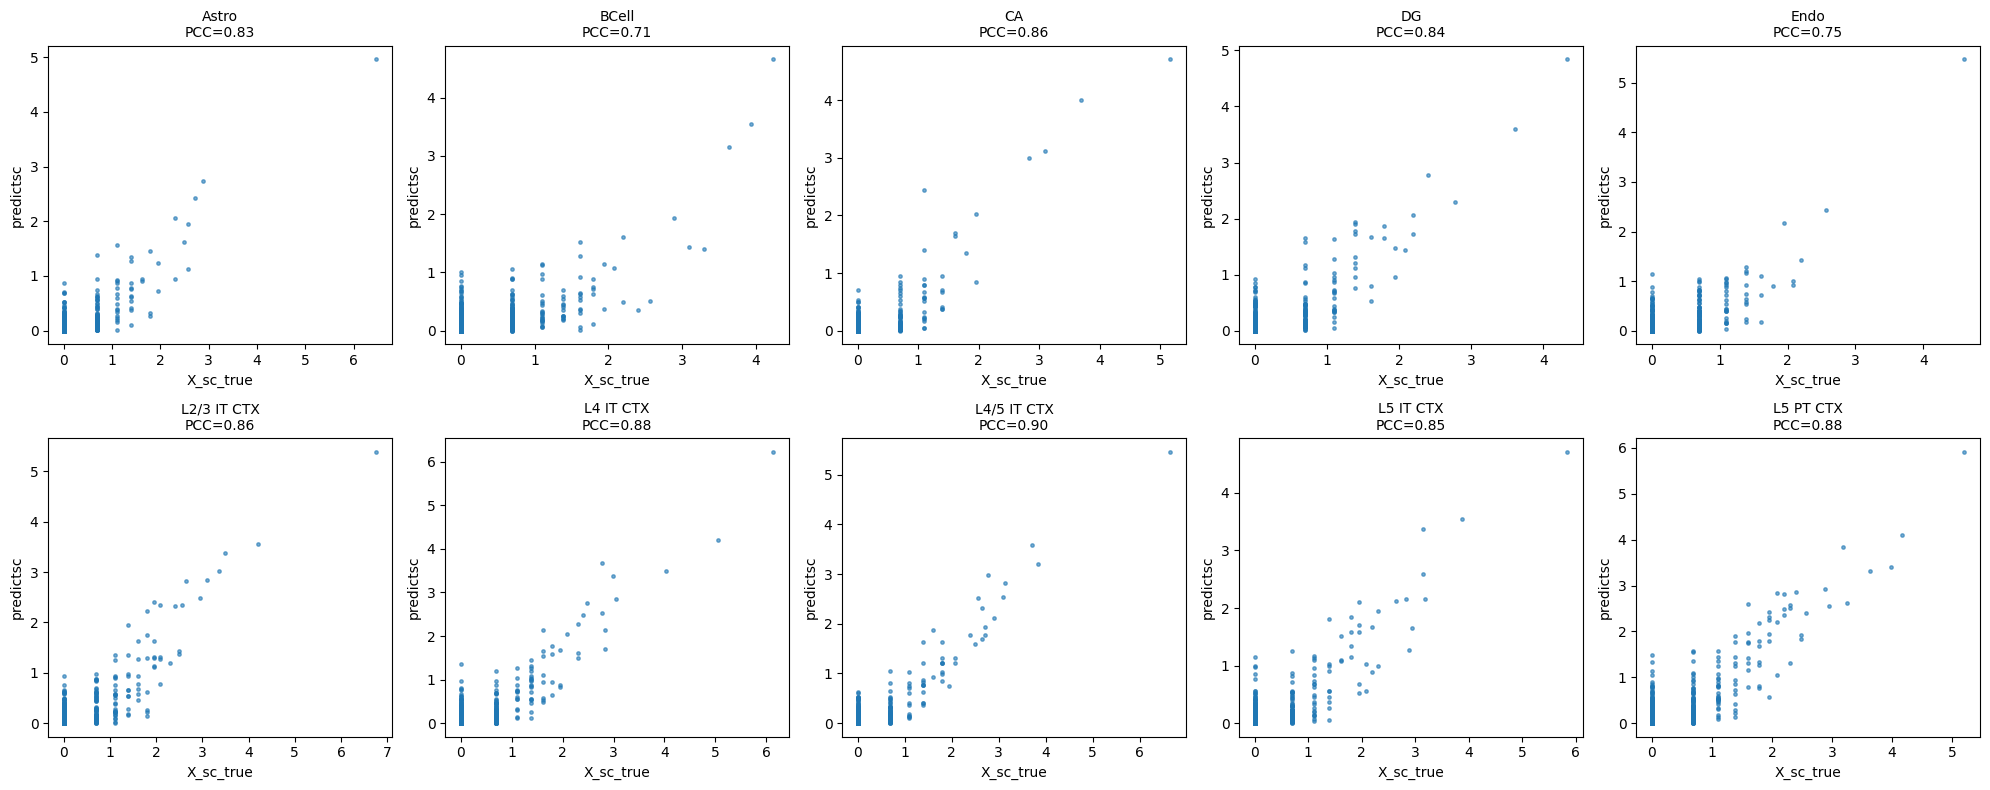

In [362]:
result_ours=evaluate_predictions_numpy(
    predictsc,              # (n_sc_cells, n_genes) or embedding
    scembeding,
    np.log(1+adata_sc.X.toarray()),              # same shape as predictsc (optional, can be None)
    predictst=X_st_pred,         # (n_spots, n_genes)
    X_st_true=np.log(1+adata_st.X.toarray()),         # (n_spots, n_genes)
    predictA=A_hat_np,          # (n_spots, n_sc_cells)
    A_gt=None,              # (n_spots, n_sc_cells) or spot × cell assignment
    cell_type_labels=cell_type_labels,  # list[str], length = n_sc_cells
    A_gt_deconv=A_gt_deconv,       # (n_spots, n_types)
    cell_types_gt_order=cell_types_gt_order
)

In [363]:
result_ours

{'predictsc_row_pcc': 0.8385047094842456,
 'predictsc_col_pcc': 0.47090201785715685,
 'predictst_row_pcc': 0.3876495244382303,
 'predictst_col_pcc': 0.16621273454263516,
 'deconv_mean_pcc': 0.41772880440528265,
 'deconv_mean_mae': 0.1961557975535695,
 'deconv_mean_rmse': 0.32476817426000076,
 'PCC_all': [0.030258604477150494,
  0.42544444374250145,
  0.3948094450632461,
  0.216702204422756,
  -0.0005604908251003934,
  0.6372713083145558,
  0.24826170185543023,
  0.3597969347254978,
  0.03013072745139281,
  0.32915904189255807,
  0.07409386310721115,
  0.5690083273649917,
  0.44690691431551005,
  0.31479342575810376,
  0.4333658571964583,
  0.8775576740785032,
  0.3060599093908627,
  0.20633257276987108,
  0.11772202697253129,
  0.25065476221372834,
  0.7335958952268786,
  0.8878022368262285,
  0.2865494534073393,
  0.6623543834796113,
  0.21016997136487747,
  0.5355115318138223,
  0.7437022177206396,
  0.09680096138145378,
  0.13351231753480566,
  0.48831170918260736,
  0.3851062285148

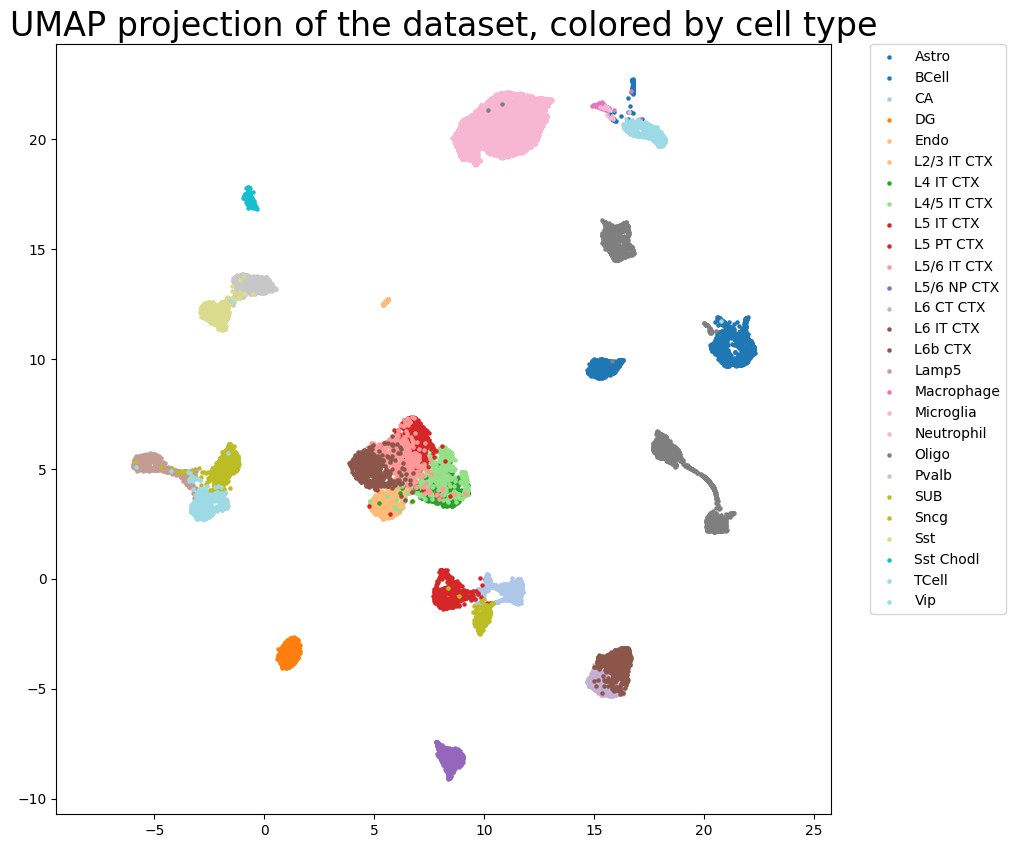

In [10]:
import umap
import matplotlib.pyplot as plt
import numpy as np

# 假设 scembedding 是你的单细胞嵌入数据，形状为 (n_cells, n_features)
# cell_type_labels 是一个包含每个细胞类型的标签列表或数组，长度为 n_cells
# 示例数据
# scembedding = ...  # 你的单细胞嵌入数据
# cell_type_labels = ...  # 你的细胞类型标签
# 使用UMAP降维
reducer = umap.UMAP()
embedding = reducer.fit_transform(scembeding)

# 获取所有独特的细胞类型用于配色
unique_cell_types = np.unique(cell_type_labels)

# 为每种细胞类型生成颜色
colors = plt.cm.get_cmap('tab20', len(unique_cell_types))

plt.figure(figsize=(10, 10))

# 绘制每个细胞类型
for i, cell_type in enumerate(unique_cell_types):
    mask = cell_type_labels == cell_type
    plt.scatter(embedding[mask, 0], embedding[mask, 1], c=[colors(i)], label=cell_type, s=5)

plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection of the dataset, colored by cell type', fontsize=24)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

In [ ]:
max_indices = np.argmax(A_hat_np, axis=0)
count_file_path='./method/stardist/count_spot/spot_loc_with_counts_r_f.csv'
Count_cell=pd.read_csv(count_file_path)
Count_cell=Count_cell.set_index(['Unnamed: 0'])
Count_cell=Count_cell.loc[A_gt_deconv.index,:]
max_values = np.max(A_hat_np, axis=0)
len(set(max_indices))

2174

Image shape: (10000, 9901, 3)
高清图像已保存至：/home/qyyuan/project/ST_CP/JE/A_matrix/count_spot/Visium_spots_jiyuanYang_HighRes.pdf
提示：如果在看图软件中依然模糊，请尝试用 Adobe Acrobat 或浏览器打开，并放大查看。


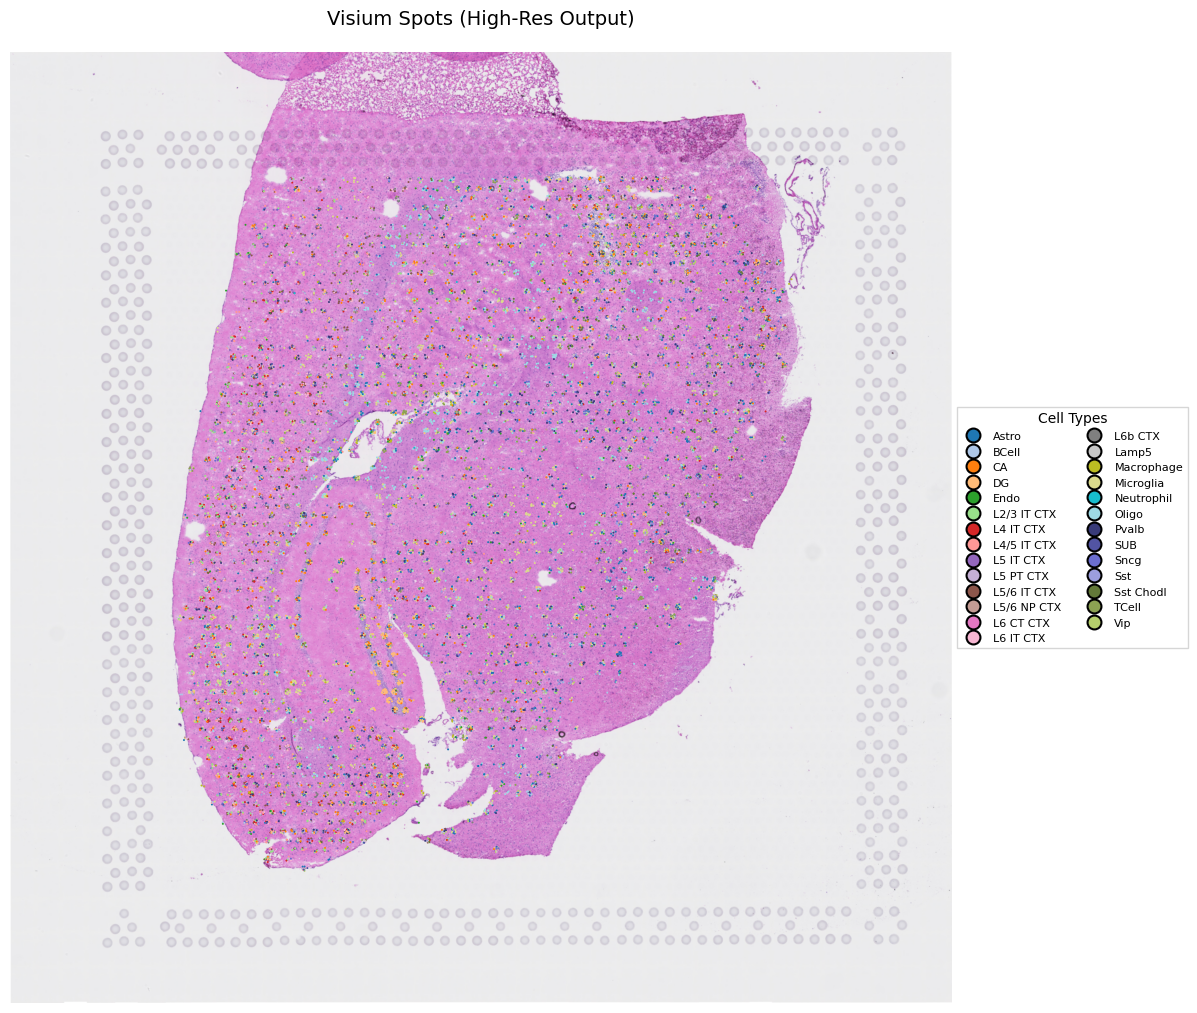

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.collections import PatchCollection
from PIL import Image

# ========= 1. 读取图像 =========
img_path = "./compare/groundtruth/NM_yangjy_X/data/VisiumImage_FAD_1.jpg"
img = np.array(Image.open(img_path))

H, W = img.shape[:2]
print("Image shape:", img.shape)
#spot_loc=pd.read_csv('./method/stardist/count_spot/spot_loc_with_counts_r_f.csv',sep=',',index_col=0)
import matplotlib.pyplot as plt
from matplotlib.collections import PatchCollection
from matplotlib.patches import Circle
import numpy as np
import random

# 假设 x, y, spot_loc, img, r 已经定义好
x = Count_cell['imagecol'].values[max_indices]
y = Count_cell['imagerow'].values[max_indices]
# ==========================================
# 1. 数据预处理
# ==========================================
r = 73.1*100/118/2
labels = cell_type_labels.tolist() # <--- 修改为你的实际列名

# 定义 27 种不同的颜色
# 方法：组合多个定性色图 (Qualitative Colormaps) 来获得足够的颜色
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm

# 获取常用的定性色图
cmap1 = cm.get_cmap('tab20')      # 20 种
cmap2 = cm.get_cmap('tab20b')     # 20 种
cmap3 = cm.get_cmap('tab20c')     # 20 种
cmap4 = cm.get_cmap('Accent')     # 8 种

# 拼接颜色数组，取前 27 个
all_colors = []
for c in [cmap1, cmap2, cmap3, cmap4]:
    for i in range(c.N):
        all_colors.append(c(i))

unique_labels = sorted(list(set(labels)))
if len(unique_labels) > 27:
    print(f"警告：检测到 {len(unique_labels)} 种标签，超过了预设的 27 种颜色，颜色可能会重复。")

# 创建标签到颜色的映射字典
label_to_color = {}
for i, label in enumerate(unique_labels):
    label_to_color[label] = all_colors[i % len(all_colors)]

# 生成每个点对应的颜色列表
face_colors = [label_to_color[lbl] for lbl in labels]

# ==========================================
# 2. 计算随机偏移后的新坐标
# ==========================================
new_x_coords = []
new_y_coords = []

# 假设 r 是你原来的半径标量，或者是一个与点数相同的数组
# 如果 r 是标量：
if np.isscalar(r):
    radii = np.full(len(x), r)
else:
    radii = np.array(r)

# 新的半径是原来的 1/20
new_r = radii / 3

for i in range(len(x)):
    cx, cy = x[i], y[i]
    radius = radii[i]
    
    # 在半径为 radius 的圆内生成随机点
    # 方法：极坐标采样 (注意：为了均匀分布，半径需要开平方)
    # 如果希望完全随机分布在原圆内：
    theta = random.uniform(0, 2 * np.pi)
    # sqrt 保证点在圆内均匀分布，而不是集中在圆心
    dist = np.sqrt(random.uniform(0, 1)) * radius 
    
    nx = cx + dist * np.cos(theta)
    ny = cy + dist * np.sin(theta)
    
    new_x_coords.append(nx)
    new_y_coords.append(ny)

# ==========================================
# 3. 画图
# ==========================================
# ==========================================
# 3. 画图 (优化版)
# ==========================================
# 创建更大的画布有助于提高细节渲染精度
fig, ax = plt.subplots(figsize=(12, 12)) # 从 8x8 增加到 12x12

# 【关键】显示图片时，确保插值方式最适合高清展示
# 'nearest' 保持像素硬边缘，'bilinear' 或 'sinc' 更平滑但可能模糊
# 对于组织切片，通常 'bilinear' 或默认即可，但如果原图很大，这里不会损失质量
ax.imshow(img, interpolation='bilinear') 

# 创建小圆点
patches = []
for xi, yi, r_val in zip(new_x_coords, new_y_coords, new_r):
    # 稍微增加最小显示半径，防止在高清屏上看不见
    display_r = max(r_val, 2.0) 
    patches.append(Circle((xi, yi), display_r))

# 绘制集合
p = PatchCollection(patches,
                    facecolor=face_colors,
                    edgecolor=None,
                    linewidth=0.0001,      # 加粗边框，从 0.5 改为 1.0，更清晰
                    rasterized=False)   # 【重要】强制使用矢量渲染，不要转成位图
ax.add_collection(p)

ax.set_aspect('equal')
ax.axis('off')
ax.set_title(f"Visium Spots (High-Res Output)", fontsize=14, pad=20)

# ==========================================
# 4. 添加图例
# ==========================================
if len(unique_labels) <= 27:
    from matplotlib.lines import Line2D
    
    legend_elements = [Line2D([0], [0], marker='o', color='w', 
                              markerfacecolor=label_to_color[lbl], 
                              markersize=10,          # 加大图例标记
                              label=lbl, 
                              markeredgecolor='black',
                              markeredgewidth=1.5)    # 加粗图例边框
                       for lbl in unique_labels]
    
    ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), 
              fontsize=8, ncol=2, frameon=True, title="Cell Types", 
              fancybox=False, shadow=False) # 简化图例背景

plt.tight_layout()

# ==========================================
# 5. 保存 (高分辨率设置)
# ==========================================
output_path = "./A_matrix/count_spot/Visium_spots_jiyuanYang_HighRes.pdf"

plt.savefig(
    output_path, 
    format='pdf', 
    bbox_inches='tight', 
    dpi=600,              # 提高 DPI，主要影响嵌入的位图部分
    metadata={'Creator': 'Matplotlib High-Res Export'}
    #pil_kwargs={'quality': 95} # 如果有位图转换，保证高质量
)
print(f"高清图像已保存至：{output_path}")
print("提示：如果在看图软件中依然模糊，请尝试用 Adobe Acrobat 或浏览器打开，并放大查看。")
plt.show()

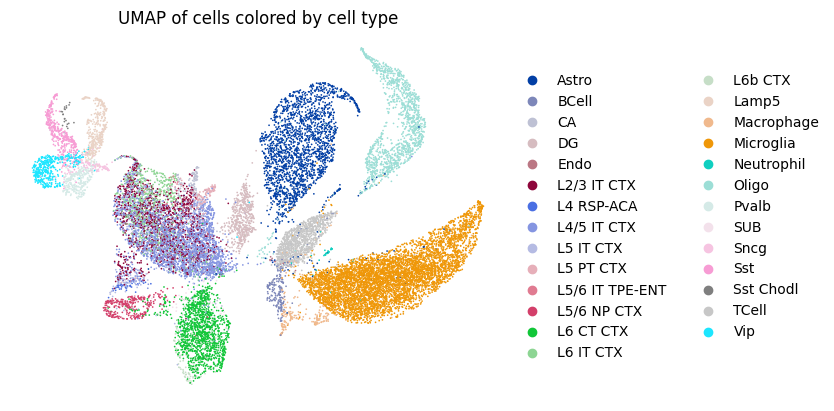

In [ ]:
import scanpy as sc
import matplotlib.pyplot as plt
sc_data_path = "./compare/groundtruth/NM_yangjy_X/data/REf_sub_20000cells.h5ad"
adata = sc.read_h5ad(sc_data_path)

metadata = pd.read_csv('./compare/groundtruth/NM_yangjy_X/data/REf_sub_20000cells_metadata.txt',sep='\t')
cell_type_labels = metadata.loc[adata_sc.obs_names,'cell_type_std'].values
adata.obs['cell_type_label'] = cell_type_labels
adata=adata[:,common_genes]
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=40)
sc.tl.umap(adata)

# 绘制 UMAP 图并根据 cell_type_label 进行染色
sc.pl.umap(adata, color='cell_type_label', title="UMAP of cells colored by cell type", frameon=False)
plt.show()

In [30]:
pca_embedding = adata.obsm['X_pca']

✅ Evaluation complete.


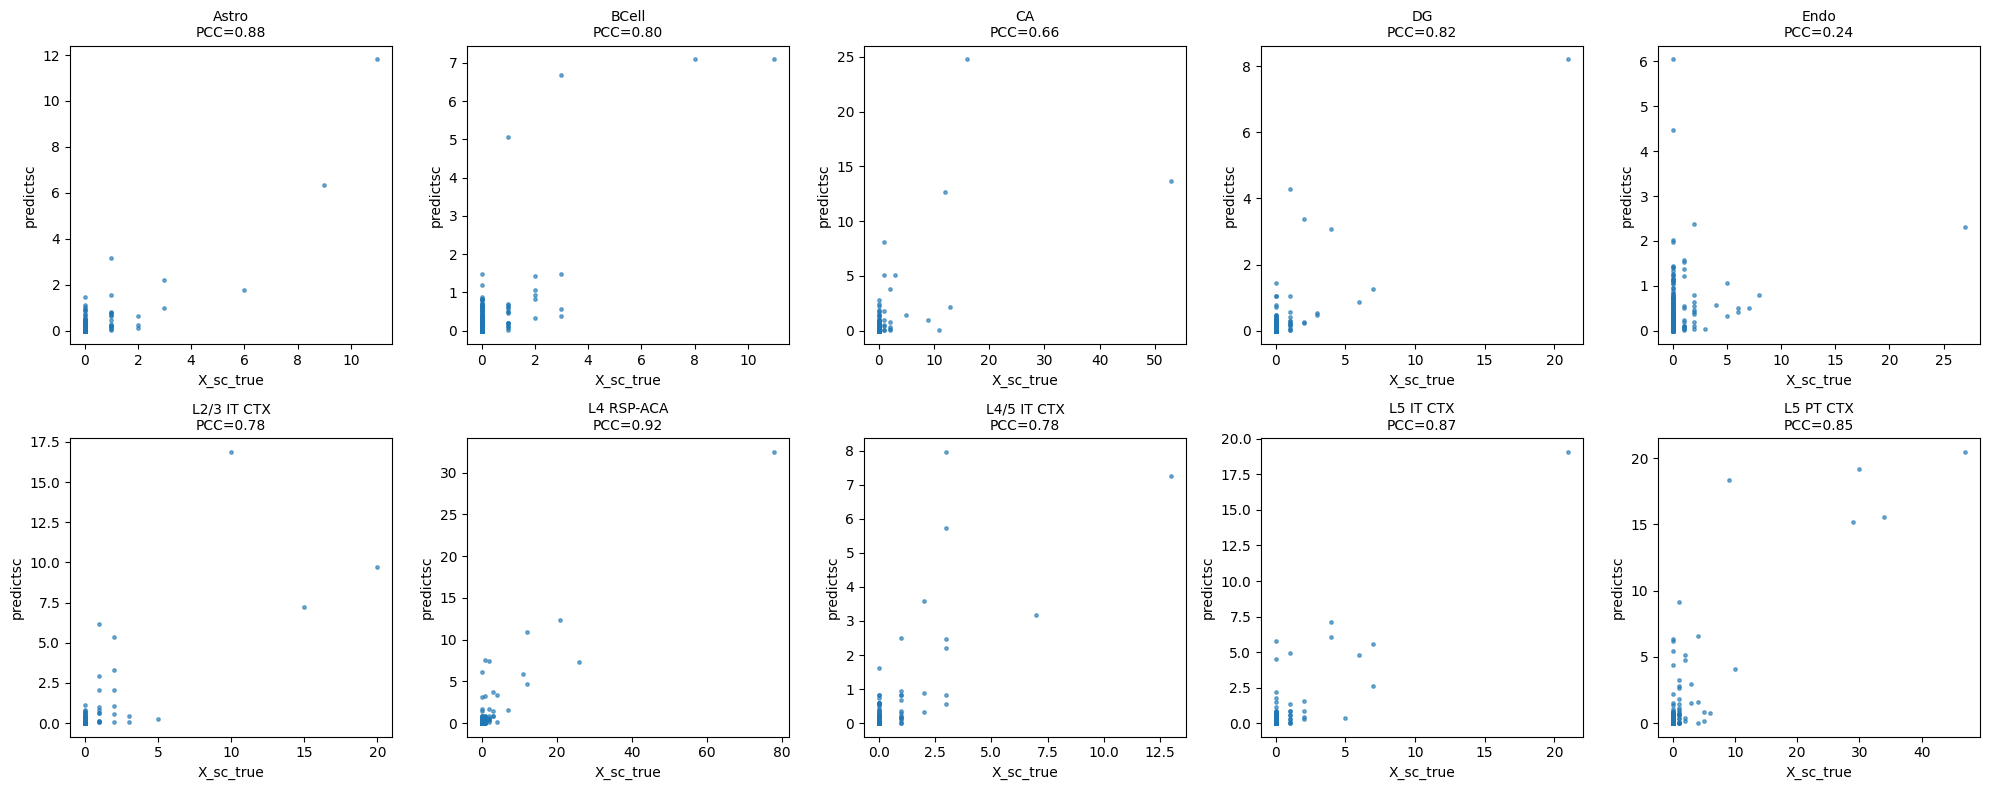

{'predictsc_row_pcc': 0.7939301494939253,
 'predictsc_col_pcc': 0.526950521855937,
 'predictst_row_pcc': 0.37036796155523927,
 'predictst_col_pcc': -0.0011630475272157012,
 'deconv_mean_pcc': 0.2762419738154912,
 'deconv_mean_mae': 0.050668327264168,
 'deconv_mean_rmse': 0.10996929975629341,
 'silhouette_index': 0.18273371807826483}

In [33]:
evaluate_predictions_numpy(
    predictsc,              # (n_sc_cells, n_genes) or embedding
    pca_embedding,
    adata_sc.X.toarray(),              # same shape as predictsc (optional, can be None)
    predictst=X_st_pred,         # (n_spots, n_genes)
    X_st_true=adata_st.X.toarray(),         # (n_spots, n_genes)
    predictA=A_hat_np,          # (n_spots, n_sc_cells)
    A_gt=None,              # (n_spots, n_sc_cells) or spot × cell assignment
    cell_type_labels=cell_type_labels,  # list[str], length = n_sc_cells
    A_gt_deconv=A_gt_deconv,       # (n_spots, n_types)
    cell_types_gt_order=cell_types_gt_order
)